In [1]:
import sys
sys.path.append('../../simulations/csf_sims/work_package_1')

import single_crystal_analysis
from single_crystal_analysis.imports import *
from surrogatetools import *
import arviz as az
import sklearn

from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

# 1. Load training, testing, and experimental data

In [2]:
# Large batch - 400 simulations
phenopowerlaw_111_params_file = './data/phenopowerlaw/train_111/phenopowerlaw_single_crystal_lhs_sams_ranges_50k_time_steps_400_sims_2026-05-29_202151_parameters_from_zero_strain.npy'
phenopowerlaw_111_outputs_file = './data/phenopowerlaw/train_111/phenopowerlaw_single_crystal_lhs_sams_ranges_50k_time_steps_400_sims_2026-05-29_202151_outputs_from_zero_strain.npy'

phenopowerlaw_001_params_file = './data/phenopowerlaw/train_001/phenopowerlaw_single_crystal_lhs_sams_ranges_001_50k_time_steps_400_sims_2026-05-29_202456_parameters_from_zero_strain.npy'
phenopowerlaw_001_outputs_file = './data/phenopowerlaw/train_001/phenopowerlaw_single_crystal_lhs_sams_ranges_001_50k_time_steps_400_sims_2026-05-29_202456_outputs_from_zero_strain.npy'

Test batches - 100 sims

In [3]:
test_pheno_111_params = np.load('./data/phenopowerlaw/test_111/phenopowerlaw_single_crystal_lhs_sams_ranges_50k_time_steps_test_100_sims_2026-06-19_115608_parameters_from_zero_strain.npy')
test_pheno_111_outputs = np.load('./data/phenopowerlaw/test_111/phenopowerlaw_single_crystal_lhs_sams_ranges_50k_time_steps_test_100_sims_2026-06-19_115608_outputs_from_zero_strain.npy')

test_pheno_001_params = np.load('./data/phenopowerlaw/test_001/phenopowerlaw_single_crystal_lhs_sams_ranges_001_50k_time_steps_test_100_sims_2026-06-19_162827_parameters_from_zero_strain.npy')
test_pheno_001_outputs = np.load('./data/phenopowerlaw/test_001/phenopowerlaw_single_crystal_lhs_sams_ranges_001_50k_time_steps_test_100_sims_2026-06-19_162827_outputs_from_zero_strain.npy')

Experimental data

In [4]:
# Load in experimental data for [111] loading from Takeuchi
exp_111_data_file = '/Users/user/Documents/extracted_data/single_crystal_copper_tensile_tests/takeuchi_111_copper_exp_elongation.csv'
exp_111_true_strain, exp_111_true_stress = single_crystal_analysis.load_exp_data(exp_111_data_file, true_data=False)

# Load in experimental data for [001] loading from Takeuchi
exp_001_data_file = '/Users/user/Documents/extracted_data/single_crystal_copper_tensile_tests/takeuchi_001_copper_exp_elongation.csv'
exp_001_true_strain, exp_001_true_stress = single_crystal_analysis.load_exp_data(exp_001_data_file, true_data=False)

In [5]:
pheno_111_params, pheno_111_outputs = single_crystal_analysis.load_LHS_outputs(phenopowerlaw_111_outputs_file, phenopowerlaw_111_params_file, filter = False)
pheno_001_params, pheno_001_outputs = single_crystal_analysis.load_LHS_outputs(phenopowerlaw_001_outputs_file, phenopowerlaw_001_params_file, filter = False)

In [6]:
for i in range(1,len(pheno_111_params[0])):
    pheno_111_params[:,i] = pheno_111_params[:,i]*1e-6
    pheno_001_params[:,i] = pheno_001_params[:,i]*1e-6

In [7]:
strain_incs = np.linspace(0.000,0.135,100)

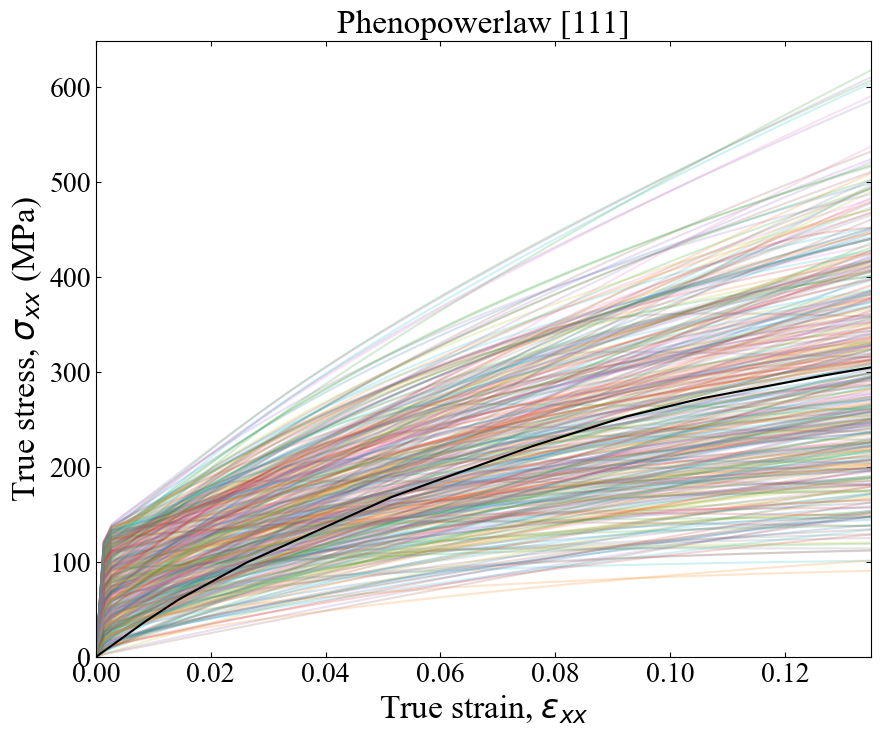

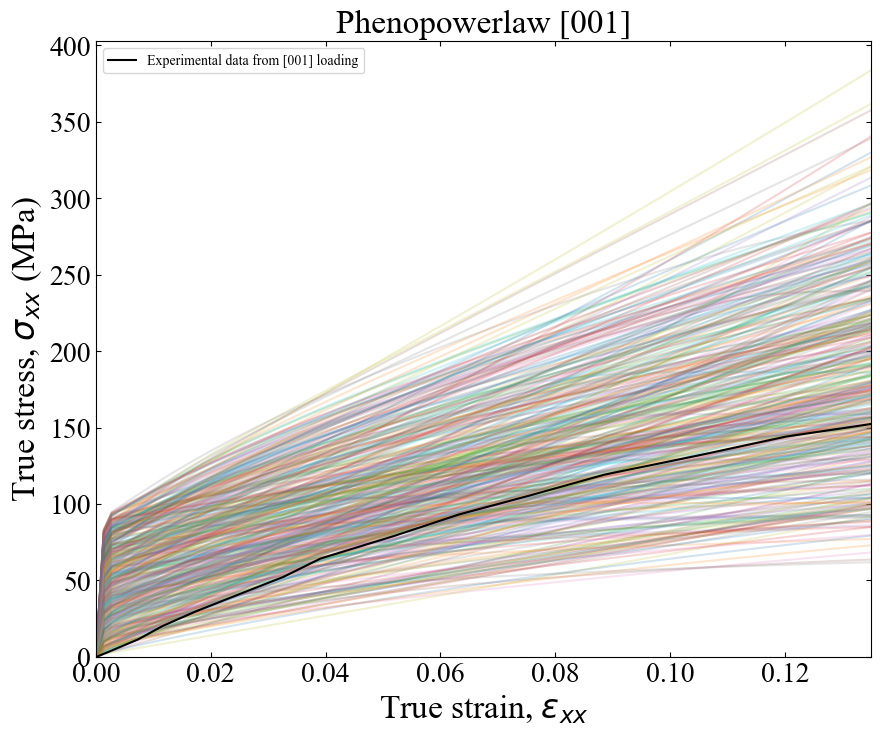

In [8]:
%matplotlib inline
single_crystal_analysis.plot_LHS_sample_stress_strain_curves(strain_incs, pheno_111_outputs, model_type = 'Phenopowerlaw [111]')
plt.plot(exp_111_true_strain, exp_111_true_stress, 'k', label = 'Experimental data from [111] loading')
plt.ylim(0)
plt.xlim(0)
single_crystal_analysis.plot_LHS_sample_stress_strain_curves(strain_incs, pheno_001_outputs, model_type = 'Phenopowerlaw [001]')
plt.plot(exp_001_true_strain, exp_001_true_stress, 'k', label = 'Experimental data from [001] loading')
plt.ylim(0)
plt.xlim(0)
plt.legend(loc = 'upper left')

In [9]:
pheno_fitting_param_names = [r'$\it{a}$', r'$\it{\xi}_{0}[\text{MPa}]$', r'$\it{\xi}_{\infty}[\text{MPa}]$', r'$\it{h}_{0}^{\it{s-s}}[\text{MPa}]$']

Training distributions

In [10]:
N_inputs_pheno = len(pheno_fitting_param_names)

Text(0.5, 0.98, 'Training Data Distributions - Phenopowerlaw [111]')

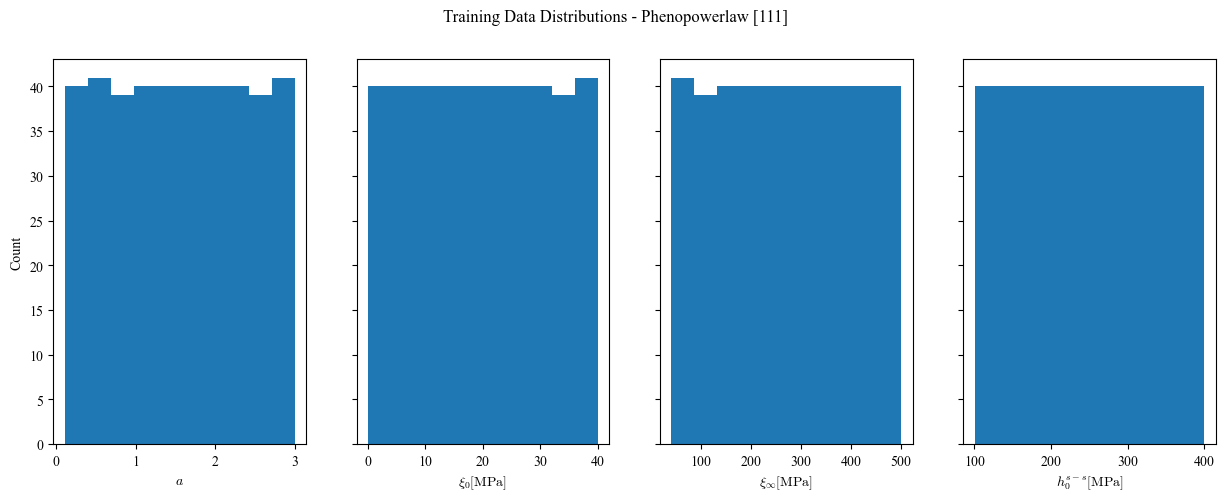

In [11]:
fig_pheno_111_train_dist,axs_pheno_111_train_dist=plt.subplots(1,N_inputs_pheno,sharey=True,figsize=(15,5))

for i in range(N_inputs_pheno):

    axs_pheno_111_train_dist[i].hist(pheno_111_params[:,i])
    axs_pheno_111_train_dist[i].set_xlabel(pheno_fitting_param_names[i], math_fontfamily = 'cm')

axs_pheno_111_train_dist[0].set_ylabel('Count')
fig_pheno_111_train_dist.suptitle('Training Data Distributions - Phenopowerlaw [111]')

Text(0.5, 0.98, 'Training Data Distributions - Phenopowerlaw [001]')

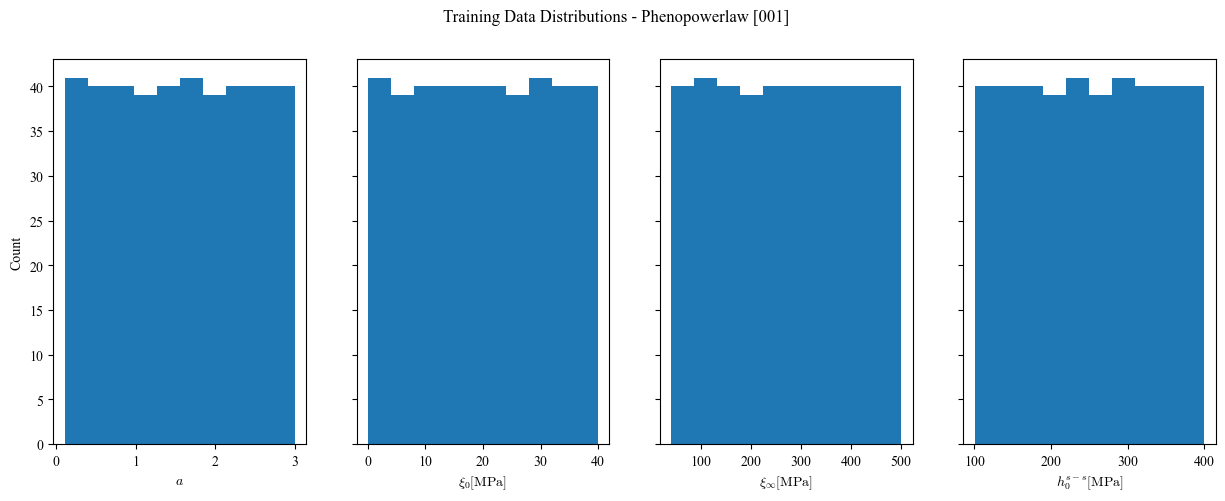

In [12]:
fig_pheno_001_train_dist,axs_pheno_001_train_dist=plt.subplots(1,N_inputs_pheno,sharey=True,figsize=(15,5))

for i in range(N_inputs_pheno):

    axs_pheno_001_train_dist[i].hist(pheno_001_params[:,i])
    axs_pheno_001_train_dist[i].set_xlabel(pheno_fitting_param_names[i], math_fontfamily = 'cm')

axs_pheno_001_train_dist[0].set_ylabel('Count')
fig_pheno_001_train_dist.suptitle('Training Data Distributions - Phenopowerlaw [001]')

In [13]:
len(pheno_111_params), len(pheno_001_outputs)

(400, 400)

# 2. Surrogate model building - Gaussian Process Regression

In [14]:
pheno_111_params = np.array(pheno_111_params)
pheno_111_outputs = np.array(pheno_111_outputs)
pheno_001_params = np.array(pheno_001_params)
pheno_001_outputs = np.array(pheno_001_outputs)
X_pheno_train_111 = pheno_111_params
Y_pheno_train_111 = pheno_111_outputs
X_pheno_train_001 = pheno_001_params
Y_pheno_train_001 = pheno_001_outputs

In [15]:
pheno_surrogates = [Surrogate(X_pheno_train_111, Y_pheno_train_111, parameter_names = pheno_fitting_param_names),
                    Surrogate(X_pheno_train_001, Y_pheno_train_001, parameter_names = pheno_fitting_param_names)]
for i in range(len(pheno_surrogates)):
    pheno_surrogates[i].scale_data()

In [16]:
for j in range(len(pheno_surrogates)):
    pheno_surrogates[j].build_model(kernel = 1.0 * Matern(length_scale=len(pheno_surrogates[j].parameter_range)*[1],length_scale_bounds = (1e-7, 1e+5), nu=2.5) + 1.0,
                            n_restarts_optimizer=5,
                            cross_validate=True,
                            scoring='r2',
                            normalize_y=True)

Cross validation score:  [1. 1. 1. 1. 1.]


/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Cross validation score:  [1. 1. 1. 1. 1.]


/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


# 3. Performance on test data

In [17]:
for i in range(1,len(test_pheno_001_params[0])):
    test_pheno_111_params[:,i] = test_pheno_111_params[:,i]*1e-6
    test_pheno_001_params[:,i] = test_pheno_001_params[:,i]*1e-6

In [18]:
Y_test_pheno_prediction_111, Y_test_pheno_error_111 = pheno_surrogates[0].make_prediction(test_pheno_111_params, return_std=True)
Y_test_pheno_prediction_001, Y_test_pheno_error_001 = pheno_surrogates[1].make_prediction(test_pheno_001_params, return_std=True)

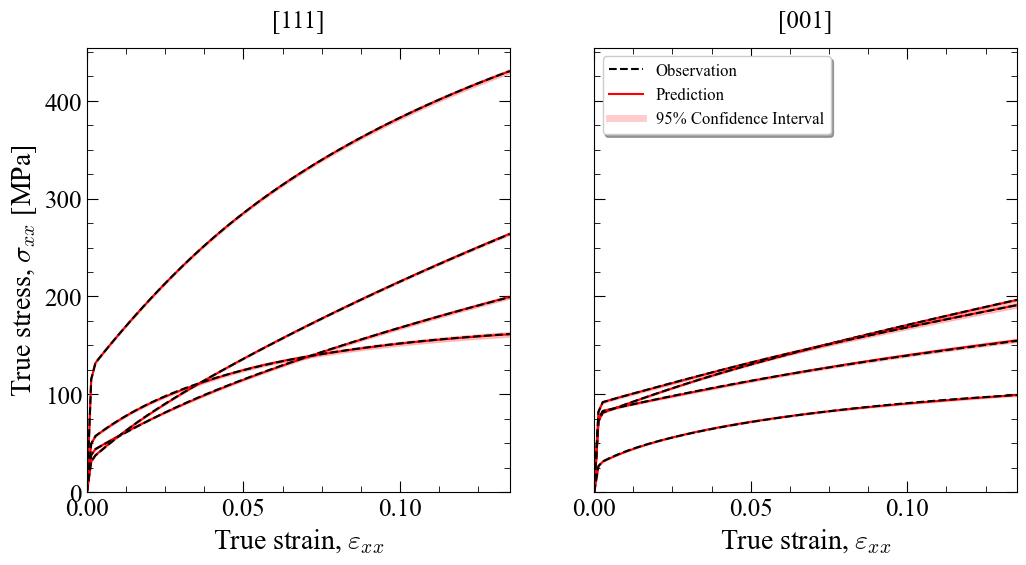

In [19]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator

fig_test, ax_test = plt.subplots(1,2, figsize = (12,6), sharex=True, sharey=True)

np.random.seed(1)

random_pheno_111_samples = np.random.randint(low=0,high=len(test_pheno_111_params), size=4)
random_pheno_001_samples = np.random.randint(low=0,high=len(test_pheno_001_params), size=4)

for idx in random_pheno_111_samples:
    ax_test[0].plot(strain_incs, Y_test_pheno_prediction_111[idx],color='r')
    ax_test[0].fill_between(strain_incs, Y_test_pheno_prediction_111[idx]+2*Y_test_pheno_error_111[idx],Y_test_pheno_prediction_111[idx]-2*Y_test_pheno_error_111[idx],alpha=0.2,color='r')
    ax_test[0].plot(strain_incs, test_pheno_111_outputs[idx],color='k',linestyle='dashed')

for idx in random_pheno_001_samples:
    ax_test[1].plot(strain_incs, Y_test_pheno_prediction_001[idx],color='r')
    ax_test[1].fill_between(strain_incs, Y_test_pheno_prediction_001[idx]+2*Y_test_pheno_error_001[idx],Y_test_pheno_prediction_001[idx]-2*Y_test_pheno_error_001[idx],alpha=0.2,color='r')
    ax_test[1].plot(strain_incs, test_pheno_001_outputs[idx],color='k',linestyle='dashed')

ax_test[0].set_xlim(min(strain_incs), max(strain_incs))
ax_test[1].set_xlim(min(strain_incs), max(strain_incs))
ax_test[0].set_ylim(0)
ax_test[1].set_ylim(0)
ax_test[0].set_xlabel(r'True strain, $\varepsilon_{xx}$', math_fontfamily = 'cm', fontsize = 20)
ax_test[1].set_xlabel(r'True strain, $\varepsilon_{xx}$', math_fontfamily = 'cm', fontsize = 20)
ax_test[0].set_ylabel(r'True stress, $\sigma_{xx}$ [MPa]', math_fontfamily = 'cm', fontsize = 20)

ax_test[0].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 18)
ax_test[0].tick_params(which = 'minor', length = 4)
ax_test[0].tick_params(which = 'major', length = 8)

ax_test[1].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 18)
ax_test[1].tick_params(which = 'minor', length = 4)
ax_test[1].tick_params(which = 'major', length = 8)

ax_test[0].xaxis.set_minor_locator(AutoMinorLocator(4))
ax_test[0].yaxis.set_minor_locator(AutoMinorLocator(4))
ax_test[1].xaxis.set_minor_locator(AutoMinorLocator(4))
ax_test[1].yaxis.set_minor_locator(AutoMinorLocator(4))

#fig_test.suptitle(r'Test Predictions of Phenomenological CP Surrogate Models', fontsize = 20)
fig_test.subplots_adjust(top=0.85)
ax_test[0].set_title('[111]', fontsize = 18, pad = 15)
ax_test[1].set_title('[001]', fontsize = 18, pad = 15)

legend_elements_pheno = [Line2D([0], [0], color='k', label='Observation',ls='dashed'),
                   Line2D([0], [0], color='r', label='Prediction'),
                   Line2D([0], [0], color='r', label='95% Confidence Interval', lw = 5, alpha=0.2)]#lw=5,alpha=0.2)]

ax_test[1].legend(handles=legend_elements_pheno, shadow = True, loc = 'upper left', fontsize = 12)
#plt.savefig('./plots/GP_performance_test_data/phenopowerlaw_stress-strain_predictions_test_data.png', dpi = 800)

Plot examples of surrogate predictions on test data

$r^2$ coefficients for training and testing data

In [20]:
# Predictions on training data
Y_train_pheno_prediction_111, Y_train_pheno_error_111 = pheno_surrogates[0].make_prediction(pheno_111_params, return_std=True)
Y_train_pheno_prediction_001, Y_train_pheno_error_001 = pheno_surrogates[1].make_prediction(pheno_001_params, return_std=True)

In [21]:
r2_score_pheno_train_111 = sklearn.metrics.r2_score(pheno_111_outputs, Y_train_pheno_prediction_111)
r2_score_pheno_train_001 = sklearn.metrics.r2_score(pheno_001_outputs, Y_train_pheno_prediction_001)

In [22]:
r2_score_pheno_test_111 = sklearn.metrics.r2_score(test_pheno_111_outputs, Y_test_pheno_prediction_111)
r2_score_pheno_test_001 = sklearn.metrics.r2_score(test_pheno_001_outputs, Y_test_pheno_prediction_001)

In [23]:
r2_score_pheno_train_111, r2_score_pheno_test_111

(1.0, 0.9994628426192643)

In [24]:
r2_score_pheno_train_001, r2_score_pheno_test_001

(1.0, 0.9996932734423818)

Root mean square relative error (RMSRE)

In [25]:
pheno_errors = []
for i in range(len(pheno_111_outputs)):
    rel_error_per_sim = (pheno_111_outputs[i] - Y_train_pheno_prediction_111[i])/pheno_111_outputs[i]
    sre_per_sim = rel_error_per_sim**2
    msre_per_sim = np.mean(sre_per_sim)
    pheno_errors.append(msre_per_sim)

pheno_111_train_rmsre = np.sqrt((1/len(pheno_111_outputs))*np.sum(pheno_errors))
pheno_111_train_rmsre

np.float64(3.909940734102266e-09)

In [77]:
def rmsre(outputs, predictions):
    errors = []
    for i in range(len(outputs)):
        rel_error_per_sim = (outputs[i] - predictions[i])/outputs[i]
        #print(rel_error_per_sim.shape)
        sre_per_sim = rel_error_per_sim**2
        #print(sre_per_sim.shape)
        msre_per_sim = np.mean(sre_per_sim)
        rmsre_per_sim = np.sqrt(msre_per_sim)
        print(rmsre_per_sim.shape)
        #errors.append(msre_per_sim)
        errors.append(rmsre_per_sim)

    #rmsre = np.mean((1/len(outputs))*np.sum(errors))
    rmsre = np.mean(errors)
    return rmsre

In [78]:
rmsre_pheno_train_111 = rmsre(pheno_111_outputs, Y_train_pheno_prediction_111)
rmsre_pheno_train_001 = rmsre(pheno_001_outputs, Y_train_pheno_prediction_001)
rmsre_pheno_test_111 = rmsre(test_pheno_111_outputs, Y_test_pheno_prediction_111)
rmsre_pheno_test_001 = rmsre(test_pheno_001_outputs, Y_test_pheno_prediction_001)

()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
()
(

In [76]:
rmsre_pheno_train_111, rmsre_pheno_train_001, rmsre_pheno_test_111, rmsre_pheno_test_001

(np.float64(2.455535839462493e-09),
 np.float64(3.6878905953890975e-09),
 np.float64(0.00540885819077164),
 np.float64(0.0030801137848419664))

Final stress prediction comparison with simulation

Training data

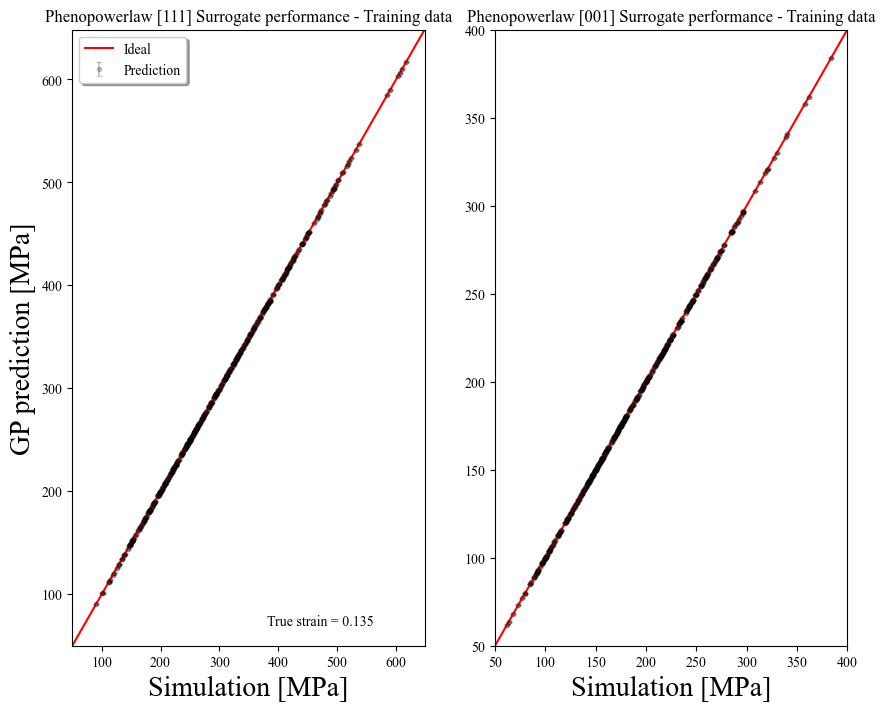

In [29]:
fig_stress, ax_stress = plt.subplots(1,2, figsize = (10,8), sharex=False, sharey=False)

ax_stress[0].plot(pheno_111_outputs[:,-1], Y_train_pheno_prediction_111[:,-1], 'ko', markersize = 3, alpha = 0.2)
ax_stress[1].plot(pheno_001_outputs[:,-1], Y_train_pheno_prediction_001[:,-1], 'ko', markersize = 3, alpha = 0.2)
ax_stress[0].errorbar(pheno_111_outputs[:,-1], Y_train_pheno_prediction_111[:,-1], Y_train_pheno_error_111[:,-1], marker = 'o', markersize = 3, linestyle = 'None', color = 'k', capsize = 2,  label = 'Prediction', alpha = 0.2)
ax_stress[1].errorbar(pheno_001_outputs[:,-1], Y_train_pheno_prediction_001[:,-1], Y_train_pheno_error_001[:,-1], marker = 'o', markersize = 3, linestyle = 'None', color = 'k', capsize = 2, alpha = 0.2)
ax_stress[0].set_xlabel('Simulation [MPa]', fontsize = 20)
ax_stress[1].set_xlabel('Simulation [MPa]', fontsize = 20)
ax_stress[0].set_ylabel('GP prediction [MPa]', fontsize = 20)
ax_stress[0].axline([0,0], slope = 1, color = 'r', label = 'Ideal')
ax_stress[1].axline([0,0], slope = 1, color = 'r', label = 'Ideal')
ax_stress[0].set_xlim(50)
ax_stress[1].set_xlim(50,400)
ax_stress[0].set_ylim(50)
ax_stress[1].set_ylim(50,400)
ax_stress[0].annotate(f'True strain = {strain_incs[-1]}', xy = (380,70))
# Include r^2 value and annotation of final strain value

ax_stress[0].set_title('Phenopowerlaw [111] Surrogate performance - Training data')
ax_stress[1].set_title('Phenopowerlaw [001] Surrogate performance - Training data')
ax_stress[0].legend(shadow = True)

Test data

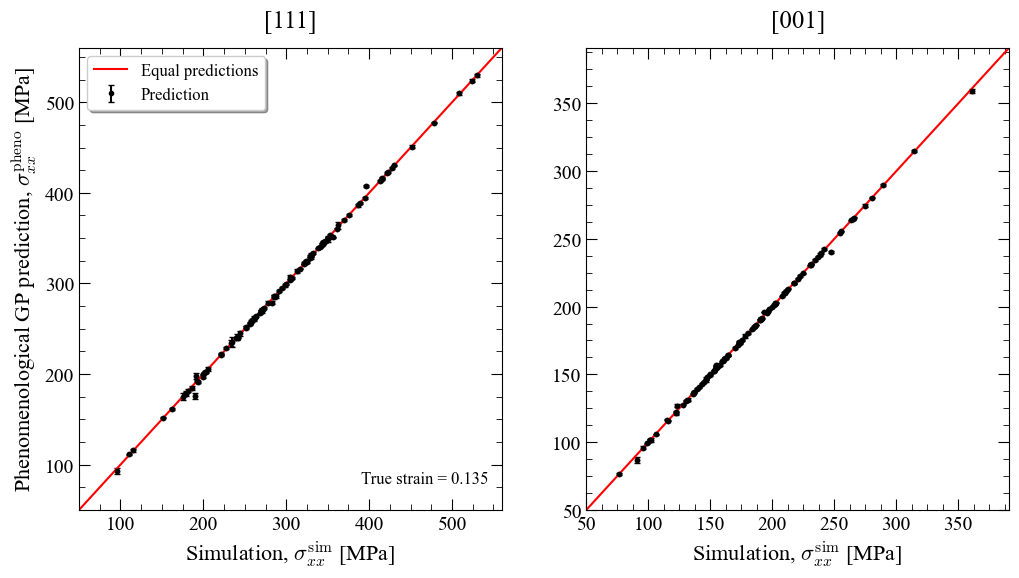

In [30]:
fig_stress, ax_stress = plt.subplots(1,2, figsize = (12,6), sharex=False, sharey=False)

ax_stress[0].plot(test_pheno_111_outputs[:,-1], Y_test_pheno_prediction_111[:,-1], 'ko', markersize = 3)
ax_stress[1].plot(test_pheno_001_outputs[:,-1], Y_test_pheno_prediction_001[:,-1], 'ko', markersize = 3)
ax_stress[0].errorbar(test_pheno_111_outputs[:,-1], Y_test_pheno_prediction_111[:,-1], Y_test_pheno_error_111[:,-1], marker = 'o', markersize = 3, linestyle = 'None', color = 'k', capsize = 2,  label = 'Prediction')
ax_stress[1].errorbar(test_pheno_001_outputs[:,-1], Y_test_pheno_prediction_001[:,-1], Y_test_pheno_error_001[:,-1], marker = 'o', markersize = 3, linestyle = 'None', color = 'k', capsize = 2)
ax_stress[0].set_xlabel(r'Simulation, $\sigma_{xx}^{\text{sim}}$ [MPa]', fontsize = 16, math_fontfamily = 'cm')
ax_stress[1].set_xlabel(r'Simulation, $\sigma_{xx}^{\text{sim}}$ [MPa]', fontsize = 16, math_fontfamily = 'cm')
ax_stress[0].set_ylabel(r'Phenomenological GP prediction, $\sigma_{xx}^{\text{pheno}}$ [MPa]', fontsize = 16, math_fontfamily = 'cm')
ax_stress[0].axline([0,0], slope = 1, color = 'r', label = 'Equal predictions')
ax_stress[1].axline([0,0], slope = 1, color = 'r', label = 'Equal predictions')
ax_stress[0].set_xlim(50, max(max(test_pheno_111_outputs[:,-1]), max(Y_test_pheno_prediction_111[:,-1])) + 30)
ax_stress[1].set_xlim(50, max(max(test_pheno_001_outputs[:,-1]), max(Y_test_pheno_prediction_001[:,-1])) + 30)
ax_stress[0].set_ylim(50, max(max(test_pheno_111_outputs[:,-1]), max(Y_test_pheno_prediction_111[:,-1])) + 30)
ax_stress[1].set_ylim(50, max(max(test_pheno_001_outputs[:,-1]), max(Y_test_pheno_prediction_001[:,-1])) + 30)
ax_stress[0].annotate(f'True strain = {strain_incs[-1]}', xy = (390,80), fontsize = 12)
# Include r^2 value and annotation of final strain value

ax_stress[0].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 14)
ax_stress[0].tick_params(which = 'minor', length = 4)
ax_stress[0].tick_params(which = 'major', length = 8)

ax_stress[1].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 14)
ax_stress[1].tick_params(which = 'minor', length = 4)
ax_stress[1].tick_params(which = 'major', length = 8)

ax_stress[0].xaxis.set_minor_locator(AutoMinorLocator(4))
ax_stress[0].yaxis.set_minor_locator(AutoMinorLocator(4))
ax_stress[1].xaxis.set_minor_locator(AutoMinorLocator(4))
ax_stress[1].yaxis.set_minor_locator(AutoMinorLocator(4))

ax_stress[0].set_title('[111]', fontsize = 18, pad = 15)
ax_stress[1].set_title('[001]', fontsize = 18, pad = 15)
ax_stress[0].legend(shadow = True, fontsize = 12)
#plt.savefig('./plots/final_stress_comparison/phenopowerlaw_test_predictions_final_stress.png', dpi = 800)

# 4. Calibration

In [43]:
%%time

def mylogloss(X,S,Y): #removed design variable D

    if len(X)!=1:
        X = np.array([X])

    Y_pred_1, Y_pred_error_1  = pheno_surrogates[0].make_prediction(X, return_std=True) # [111] surrogate
    Y_pred_2, Y_pred_error_2  = pheno_surrogates[1].make_prediction(X, return_std=True) # [001] surrogate

    Y_pred = np.vstack([Y_pred_1,Y_pred_2])
    Y_pred_error = np.vstack([Y_pred_error_1,Y_pred_error_2])

    s2 = (S)**2
    ### Error 1 ###
    #s2 = (np.abs(S)*Y_pred + 5)**2 # + np.linspace(5,0,len(strain_incs))

    ### Error 2 ###

    #smax = np.ones_like(Y_pred)*5 #threshold uncertainty in stress values
    #smax_choice = np.maximum(smax, S*Y_pred) #np.maximum
    #s2 = (smax_choice)**2

    ### Error 3 ###
    # 2% strain cropping
    #strain_incs_cropped_min = [strain_inc for strain_inc in strain_incs if strain_inc < 0.02]
    #strain_incs_cropped_max = [strain_inc for strain_inc in strain_incs if strain_inc >= 0.02]

    #s_max_111 = np.ones_like(strain_incs_cropped_min)*5
    #s_max_001 = np.ones_like(strain_incs_cropped_min)*5

    #Y_pred_111_cropped = Y_pred[0][len(strain_incs_cropped_min):]
    #Y_pred_001_cropped = Y_pred[1][len(strain_incs_cropped_min):]

    #s_prop_111 = np.ones_like(strain_incs_cropped_max)*(np.abs(S)*Y_pred_111_cropped)
    #s_prop_001 = np.ones_like(strain_incs_cropped_max)*(np.abs(S)*Y_pred_001_cropped)

    #s_111 = np.append(s_max_111, s_prop_111)
    #s_001 = np.append(s_max_001, s_prop_001)
    #print(s_111.shape)
    
    #s = np.vstack([s_111, s_001])
    #print(s.shape)

    #s2 = (s)**2

    error = (0.5*(Y_pred - Y)**2/s2 + 0.5*np.log(2*np.pi*s2))

    return -1*float(error.sum())

def neglogloss(X,S,Y): #removed design variable D

    return -1*mylogloss(X,S,Y)


from typing import Optional, Tuple
import pymc as pm
import pytensor
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
import numpy as np
# define a pytensor Op for our likelihood function

def compile_likelihood(model,params,sigma,data): #removed design variable
    class LogLike(Op):
        def make_node(self,params, sigma, data) -> Apply:
            # Convert inputs to tensor variables
            params = pt.as_tensor(params)
            sigma = pt.as_tensor(sigma)
            #design = pt.as_tensor(design)
            data = pt.as_tensor(data)

            inputs = [params, sigma, data]
            # Define output type, in our case a vector of likelihoods
            # with the same dimensions and same data type as data
            # If data must always be a vector, we could have hard-coded
            # outputs = [pt.vector()]
            outputs = [pt.scalar()]

            # Apply is an object that combines inputs, outputs and an Op (self)
            return Apply(self, inputs, outputs)

        def perform(self, node: Apply, inputs: list[np.ndarray], outputs: list[list[None]]) -> None:
            # This is the method that compute numerical output
            # given numerical inputs. Everything here is numpy arrays
            params, sigma, data = inputs  # this will contain my variables

            # call our numpy log-likelihood function
            loglike_eval = mylogloss(params, sigma, data)

            # Save the result in the outputs list provided by PyTensor
            # There is one list per output, each containing another list
            # pre-populated with a `None` where the result should be saved.
            outputs[0][0] = np.asarray(loglike_eval)

    # create our Op
    loglike_op = LogLike()

    def custom_dist_loglike(data, params, sigma):
        # data, or observed is always passed as the first input of CustomDist
        return loglike_op(params, sigma, data)

    # use PyMC to sampler from log-likelihood
    with model:

        # use a CustomDist with a custom logp function
        likelihood = pm.CustomDist(
            "likelihood", params, sigma, observed=data, logp=custom_dist_loglike
        )

    ip = model.initial_point()

    model.compile_logp(vars=[likelihood], sum=True)(ip)

    return model

CPU times: user 20 μs, sys: 4 μs, total: 24 μs
Wall time: 25.7 μs


In [32]:
interp_exp_111_stress = single_crystal_analysis.interp_exp_data(exp_111_true_strain, exp_111_true_stress, strain_incs)
interp_exp_001_stress = single_crystal_analysis.interp_exp_data(exp_001_true_strain, exp_001_true_stress, strain_incs)
interp_exp_stress = [interp_exp_111_stress, interp_exp_001_stress]

In [33]:
Y_exp_data = interp_exp_stress
Y_exp_vstack = np.vstack([Y_exp_data[0], Y_exp_data[1]])
Y_exp_vstack.shape

(2, 100)

In [34]:
# Combined parameter ranges
combined_pheno_param_range = []
for i in range(len(pheno_surrogates[0].parameter_range)):
    min_pheno_param_value = max(pheno_surrogates[0].parameter_range[:,0][i], pheno_surrogates[1].parameter_range[:,0][i])
    max_pheno_param_value = min(pheno_surrogates[0].parameter_range[:,1][i], pheno_surrogates[1].parameter_range[:,1][i])
    combined_pheno_param_range.append([min_pheno_param_value, max_pheno_param_value])

combined_pheno_param_range = np.array(combined_pheno_param_range)

Ensure optimiser searches within central 95% of parameter range to ensure start point for Bayesian inference is suitable

In [35]:
pheno_param_diff = combined_pheno_param_range[:,1] - combined_pheno_param_range[:,0]
pheno_param_cut_off_5_percent = 0.05*pheno_param_diff

4a. Differential evolution global optimisation prediction

In [ ]:
# MAP estimate
S_exp = 5

bounds = scipy.optimize.Bounds(lb=combined_pheno_param_range[:,0]+pheno_param_cut_off_5_percent ,ub=combined_pheno_param_range[:,1]-pheno_param_cut_off_5_percent)
#bounds = scipy.optimize.Bounds(lb=combined_pheno_param_range[:,0] ,ub=combined_pheno_param_range[:,1])

pheno_res_diff_evo = scipy.optimize.differential_evolution(neglogloss,
                                            args=(S_exp, Y_exp_vstack),
                                            bounds=bounds,
                                            )

pheno_res_shgo = scipy.optimize.shgo(neglogloss,
                                     args=(S_exp, Y_exp_vstack),
                                     bounds=bounds,
                                     iters = 5,
                                     n = 250)

print(pheno_res_diff_evo.x, pheno_res_shgo.x)

[  0.86717421   7.11682593 420.29568691 231.15629416] [  1.87739235   6.54654546 321.76239303 283.73297378]


In [58]:
pheno_res_diff_evo.fun, pheno_res_shgo.fun

(177570143.3539613, np.float64(202665767.42233592))

In [59]:
Y_diff_evo_pheno_prediction_111, Y_diff_evo_pheno_prediction_error_111 = pheno_surrogates[0].make_prediction(X = pheno_res_diff_evo.x.reshape(1,-1), return_std=True)
Y_diff_evo_pheno_prediction_001, Y_diff_evo_pheno_prediction_error_001 = pheno_surrogates[1].make_prediction(X = pheno_res_diff_evo.x.reshape(1,-1), return_std=True)

Y_shgo_pheno_prediction_111, Y_shgo_pheno_prediction_error_111 = pheno_surrogates[0].make_prediction(X = pheno_res_shgo.x.reshape(1,-1), return_std=True)
Y_shgo_pheno_prediction_001, Y_shgo_pheno_prediction_error_001 = pheno_surrogates[1].make_prediction(X = pheno_res_shgo.x.reshape(1,-1), return_std=True)

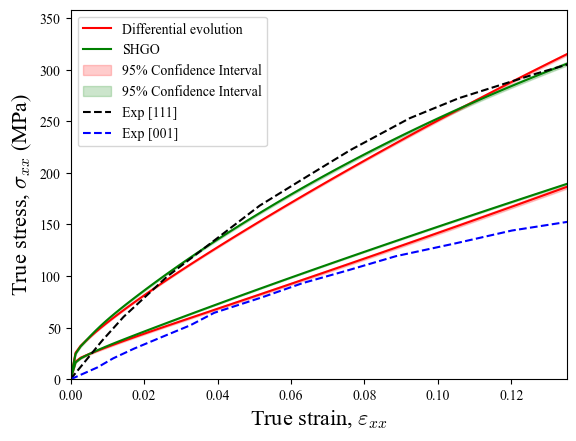

In [60]:
plt.plot(strain_incs, Y_diff_evo_pheno_prediction_111[0], color = 'r', label = 'Differential evolution')
plt.plot(strain_incs, Y_diff_evo_pheno_prediction_001[0], color = 'r')
plt.plot(strain_incs, Y_shgo_pheno_prediction_111[0], label = 'SHGO', color = 'g')
plt.plot(strain_incs, Y_shgo_pheno_prediction_001[0], color = 'g')
plt.fill_between(strain_incs, Y_diff_evo_pheno_prediction_111[0]-2*Y_diff_evo_pheno_prediction_error_111[0], Y_diff_evo_pheno_prediction_111[0]+2*Y_diff_evo_pheno_prediction_error_111[0], alpha = 0.2, color = 'r', label = '95% Confidence Interval')
plt.fill_between(strain_incs, Y_diff_evo_pheno_prediction_001[0]-2*Y_diff_evo_pheno_prediction_error_001[0], Y_diff_evo_pheno_prediction_001[0]+2*Y_diff_evo_pheno_prediction_error_001[0], alpha = 0.2, color = 'r')
plt.fill_between(strain_incs, Y_shgo_pheno_prediction_111[0]-2*Y_shgo_pheno_prediction_error_111[0], Y_shgo_pheno_prediction_111[0]+2*Y_shgo_pheno_prediction_error_111[0], alpha = 0.2, color = 'g', label = '95% Confidence Interval')
plt.fill_between(strain_incs, Y_shgo_pheno_prediction_001[0]-2*Y_shgo_pheno_prediction_error_001[0], Y_shgo_pheno_prediction_001[0]+2*Y_shgo_pheno_prediction_error_001[0], alpha = 0.2, color = 'g')
plt.plot(exp_111_true_strain, exp_111_true_stress, 'k--', label = 'Exp [111]')
plt.plot(exp_001_true_strain, exp_001_true_stress, 'b--', label = 'Exp [001]')
plt.ylabel(r'True stress, $\sigma_{xx}$ (MPa)', fontsize=16, math_fontfamily = 'cm')
plt.xlabel(r'True strain, $\varepsilon_{xx}$', fontsize=16, math_fontfamily = 'cm')
plt.xlim(0,max(strain_incs))
plt.ylim(0)
plt.legend()

4b. Bayesian inference

In [61]:
draws = 50_000
tune = 50_000
chains = 4
cores = 4

pheno_idata_prior = []
with pm.Model() as pheno_no_grad_model:

    pheno_params = []

    for i in range(pheno_surrogates[0].D):
        
        pheno_distribution = pm.Uniform(pheno_surrogates[0].parameter_names[i], 
                                  lower=combined_pheno_param_range[:,0][i], 
                                  upper=combined_pheno_param_range[:,1][i],
                                  initval=pheno_res_diff_evo.x[i]
                                  )
        pheno_params.append(pheno_distribution)
    
    #params = pm.Uniform(name='params',lower=dislo_surrogates[0].parameter_range[:,0],upper=dislo_surrogates[0].parameter_range[:,1],initval=res.x)
    #params = pm.Uniform(name='params',lower=combined_pheno_param_range[:,0],upper=combined_pheno_param_range[:,1],initval=res.x)
    pheno_sigma_nu = pm.Uniform(name='sigma', lower=0.01, upper=8) # S_exp

    pheno_no_grad_model = compile_likelihood(pheno_no_grad_model, pheno_params, pheno_sigma_nu, Y_exp_vstack)

    step = pm.DEMetropolisZ()

    pheno_idata = pm.sample(step=step,draws=draws,tune=tune,cores=cores,chains=chains,return_inferencedata=True)

    pheno_idata_prior.append(pheno_idata)

Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [$\it{a}$, $\it{\xi}_{0}[\text{MPa}]$, $\it{\xi}_{\infty}[\text{MPa}]$, $\it{h}_{0}^{\it{s-s}}[\text{MPa}]$, sigma]
INFO:pymc.sampling.mcmc:DEMetropolisZ: [$\it{a}$, $\it{\xi}_{0}[\text{MPa}]$, $\it{\xi}_{\infty}[\text{MPa}]$, $\it{h}_{0}^{\it{s-s}}[\text{MPa}]$, sigma]


Output()

Sampling 4 chains for 50_000 tune and 50_000 draw iterations (200_000 + 200_000 draws total) took 41 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 50_000 tune and 50_000 draw iterations (200_000 + 200_000 draws total) took 41 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc.stats.convergence:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [62]:
az.summary(pheno_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\it{a}$,0.348,0.419,0.106,1.186,0.202,0.126,7.0,28.0,1.53
$\it{\xi}_{0}[\text{MPa}]$,7.757,0.539,6.716,8.727,0.186,0.086,10.0,28.0,1.33
$\it{\xi}_{\infty}[\text{MPa}]$,222.151,146.847,125.374,499.598,72.735,42.652,7.0,28.0,1.53
$\it{h}_{0}^{\it{s-s}}[\text{MPa}]$,219.668,8.643,208.984,237.851,3.797,2.340,7.0,28.0,1.51
sigma,7.976,0.023,7.934,8.000,0.000,0.000,7135.0,7626.0,1.00


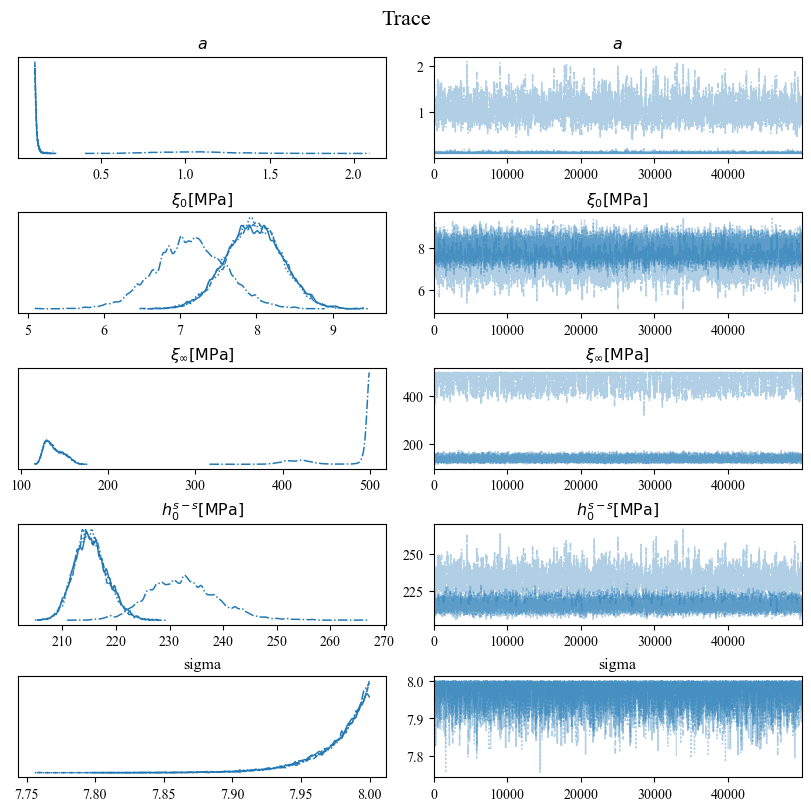

In [63]:
pheno_axes = az.plot_trace(
    data=pheno_idata,
    #var_names = 'params',
    #coords = {'params_dim_0': i},
    compact=True,
    backend_kwargs={"figsize": (12, 9), "layout": "constrained"},
    )
plt.gcf().suptitle("Trace", fontsize=16);
plt.gcf().set_figwidth(8)
plt.gcf().set_figheight(8)

In [ ]:
#az.to_netcdf(pheno_idata, './phenopowerlaw_parameter_traces_2_percent_strain_err_50k_draws_second_year_report.netcdf')

'./phenopowerlaw_parameter_traces_2_percent_strain_err_50k_draws_second_year_report.netcdf'

Import parameter trace

In [33]:
pheno_imported_idata = az.from_netcdf('./parameter_traces/phenopowerlaw_parameter_traces_2_percent_strain_err_50k_draws_second_year_report.netcdf')

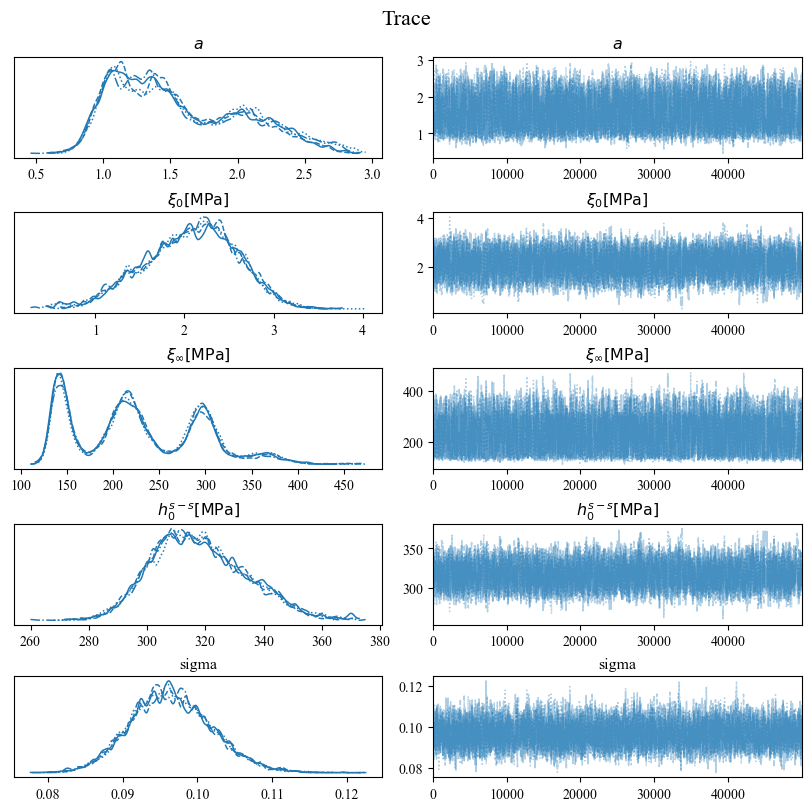

In [34]:
%matplotlib inline
pheno_imported_axes = az.plot_trace(
    data=pheno_imported_idata,
    #var_names = 'params',
    #coords = {'params_dim_0': i},
    compact=True,
    backend_kwargs={"figsize": (12, 9), "layout": "constrained"},
    )
plt.gcf().suptitle("Trace", fontsize=16);
plt.gcf().set_figwidth(8)
plt.gcf().set_figheight(8)

In [36]:
X_posterior_pheno = np.array([np.array(pheno_imported_idata.posterior[x]).flatten() for x in pheno_surrogates[0].parameter_names]).T
X_mode_pheno = np.array([scipy.stats.mode(X_posterior_pheno[:,i])[0] for i in range(len(pheno_surrogates[0].parameter_names))])
X_mean_pheno = np.array([np.mean(X_posterior_pheno[:,i]) for i in range(len(pheno_surrogates[0].parameter_names))])
X_std_pheno = np.array([np.std(X_posterior_pheno[:,i]) for i in range(len(pheno_surrogates[0].parameter_names))])

S_mode_pheno = scipy.stats.mode(np.array(pheno_imported_idata.posterior['sigma']).flatten())

In [37]:
X_mode_pheno, X_mean_pheno

(array([  1.89637097,   2.39997351, 300.55992656, 303.53120977]),
 array([  1.56083756,   2.06858425, 227.32132267, 317.96450633]))

# 5. Gaussian fits and correlation plots

In [38]:
def gaussian(x, mu, sigma, a):
    return a*np.exp(-((x-mu)**2)/(2*(sigma)**2))

def dual_gaussian(x, mu_1, mu_2, sigma_1, sigma_2, a1, a2):
    return a1*np.exp(-((x-mu_1)**2)/(2*sigma_1**2)) + a2*np.exp(-((x-mu_2)**2)/(2*sigma_2**2))

def triple_gaussian(x, mu_1, mu_2, mu_3, sigma_1, sigma_2, sigma_3, a1, a2, a3):
    return a1*np.exp(-((x-mu_1)**2)/(2*sigma_1**2)) + a2*np.exp(-((x-mu_2)**2)/(2*sigma_2**2)) + a3*np.exp(-((x-mu_3)**2)/(2*sigma_3**2))

def quad_gaussian(x, mu_1, mu_2, mu_3, mu_4, sigma_1, sigma_2, sigma_3, sigma_4, a1, a2, a3, a4):
    return a1*np.exp(-((x-mu_1)**2)/(2*sigma_1**2)) + a2*np.exp(-((x-mu_2)**2)/(2*sigma_2**2)) + a3*np.exp(-((x-mu_3)**2)/(2*sigma_3**2)) + a4*np.exp(-((x-mu_4)**2)/(2*sigma_4**2))

In [39]:
def find_means_and_stdevs(posterior_vals, gaussian_type, guess, param_range):
    counts, bins, _ = plt.hist(posterior_vals, bins=100, facecolor = 'b')
    xbins = bins[:-1] + (bins[1]-bins[0])/2
    pars, covs = scipy.optimize.curve_fit(gaussian_type, xbins, counts, p0 = guess)
    param_vals = np.linspace(param_range[0], param_range[1], 1000)
    plt.plot(param_vals, gaussian_type(param_vals, *pars))
    if gaussian_type == gaussian:
        means = pars[0]
        stdevs = pars[1]
    if gaussian_type == dual_gaussian:
        means = [pars[0], pars[1]]
        stdevs = [pars[2]], pars[3]
    if gaussian_type == triple_gaussian:
        means = [pars[0], pars[1], pars[2]]
        stdevs = [pars[3], pars[4], pars[5]]
    if gaussian_type == quad_gaussian:
        means = [pars[0], pars[1], pars[2], pars[3]]
        stdevs = [pars[4], pars[5], pars[6], pars[7]]
    return means, stdevs

([np.float64(1.057229611938016), np.float64(1.391839756928533), np.float64(2.0455617467135188)], [np.float64(0.12233077565883961), np.float64(0.15597094626729968), np.float64(0.33373095066702185)])


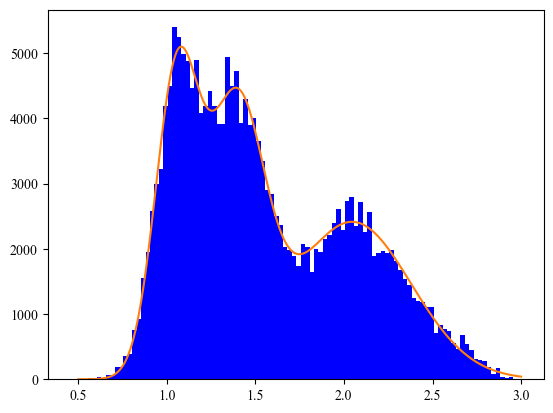

In [40]:
p0_a = [1, 1.5, 2, 0.1, 0.1, 0.1, 5000, 4000, 3000]
a_means_and_stdevs = find_means_and_stdevs(X_posterior_pheno[:,0], triple_gaussian, p0_a, [0.5,3])
print(a_means_and_stdevs)

(np.float64(2.1157748057658714), np.float64(0.5270720566287039))


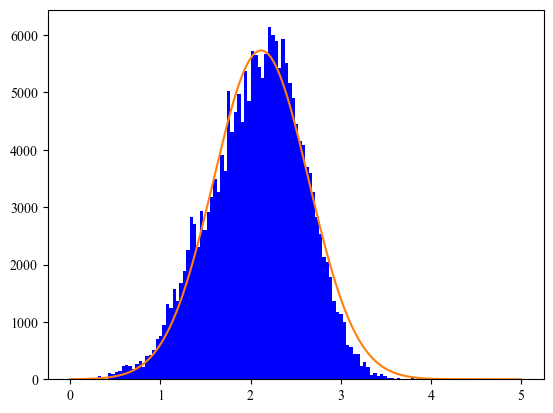

In [41]:
p0_xi_0 = [2, 0.2, 7000]
xi_0_mean_and_stdev = find_means_and_stdevs(X_posterior_pheno[:,1], gaussian, p0_xi_0, [0,5])
print(xi_0_mean_and_stdev)

([np.float64(142.5790011963368), np.float64(215.00864092745027), np.float64(296.31524287962634)], [np.float64(9.057801794570047), np.float64(19.669918973538017), np.float64(15.397513834526102)])


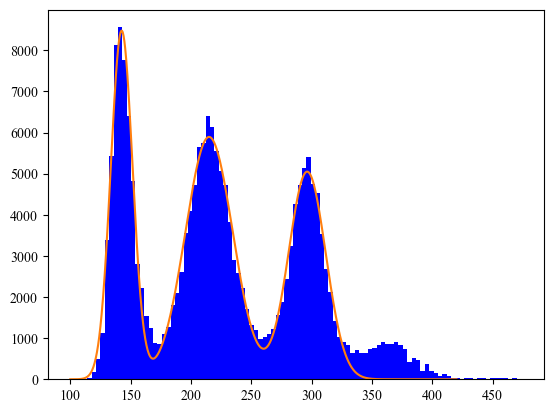

In [42]:
p0_xi_inf = [150, 200, 300, 1, 1, 1, 7200, 4000, 4000]
xi_inf_means_and_stdevs = find_means_and_stdevs(X_posterior_pheno[:,2], triple_gaussian, p0_xi_inf, [100,420])
print(xi_inf_means_and_stdevs)

(np.float64(315.9437554128178), np.float64(16.216938327161248))


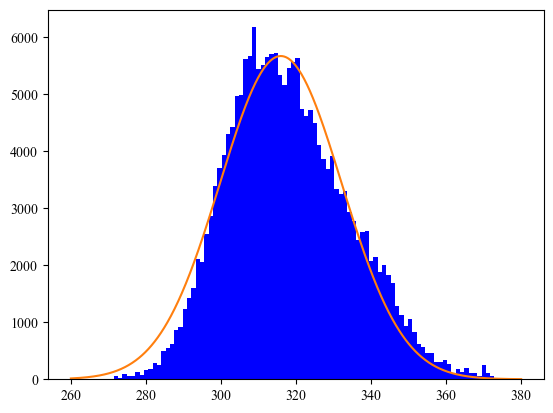

In [43]:
p0_h_0 = [300, 1, 6000]

h_0_mean_and_stdev = find_means_and_stdevs(X_posterior_pheno[:,3], gaussian, p0_h_0, [260,380])
print(h_0_mean_and_stdev)

In [44]:
S_pheno_posterior = np.array(pheno_imported_idata.posterior['sigma']).flatten()

(np.float64(0.09622441625786665), np.float64(0.005376663396923599))


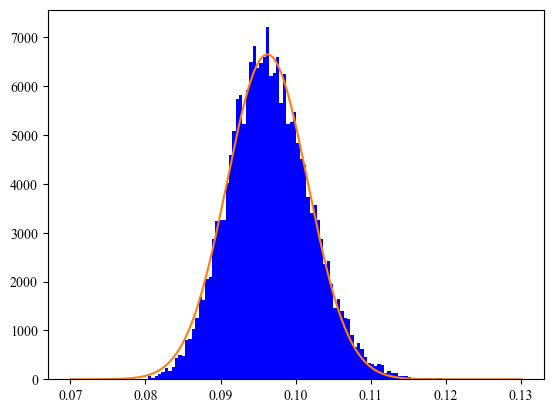

In [45]:
p0_S = [0.1, 0.01, 6000]
S_pheno_mean_and_stdev = find_means_and_stdevs(S_pheno_posterior, gaussian, p0_S, param_range=[0.07, 0.13])
print(S_pheno_mean_and_stdev)

Galaxy plot

In [46]:
from matplotlib.ticker import AutoMinorLocator, AutoLocator

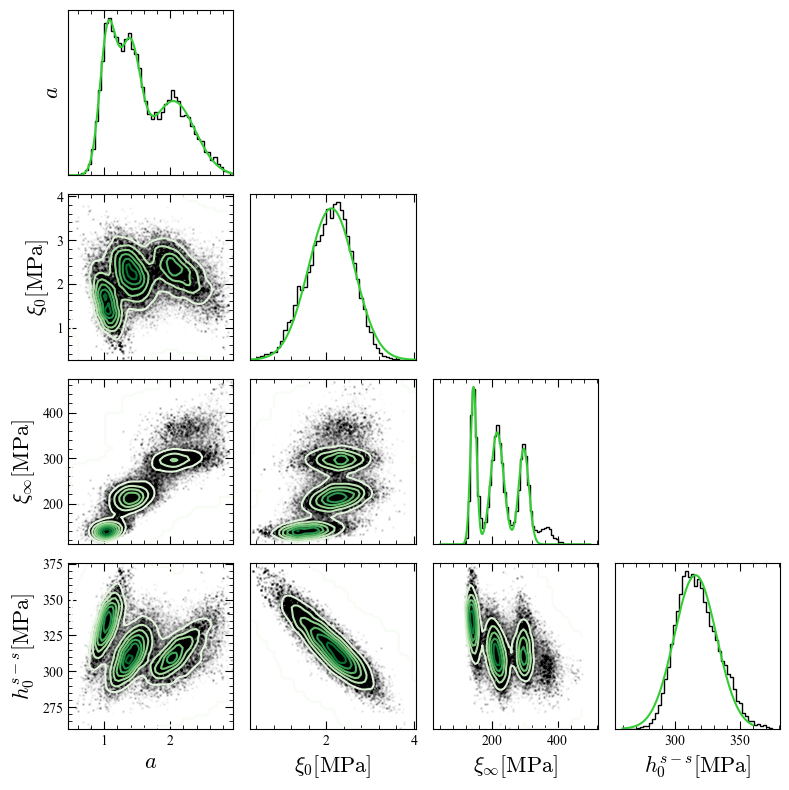

In [47]:
fig_galaxy,ax_galaxy=plt.subplots(len(X_posterior_pheno[0]),len(X_posterior_pheno[0]),figsize=(8,8), sharex='col')
#fig_galaxy.suptitle(f'{1-p}{1-p}1 loading')

for i in range(len(pheno_fitting_param_names)):

    #if i == 2:
        #pheno_param_vals_i = np.linspace(110, 420, 1000)

    for j in range(len(pheno_fitting_param_names)):

        #if j == 2:
            #pheno_param_vals_j = np.linspace(110, 420, 1000)

        if i==j:
            #if j == 2:
            #    pheno_param_counts, pheno_param_bins, _ = ax_galaxy[j,i].hist(X_posterior_pheno[:,j],bins=50, range = (min(pheno_param_vals_j), max(pheno_param_vals_j)), facecolor = 'None', edgecolor = 'k', histtype = 'step')
            #else:
            pheno_param_counts, pheno_param_bins, _ = ax_galaxy[j,i].hist(X_posterior_pheno[:,j],bins=50, facecolor = 'None', edgecolor = 'k', histtype = 'step')
            
            pheno_param_xbins = pheno_param_bins[:-1] + (pheno_param_bins[1]-pheno_param_bins[0])/2
            if j == 0:
                fit_type = triple_gaussian
                p0 = p0_a
            if j == 1:
                fit_type = gaussian
                p0 = p0_xi_0
            if j == 2:
                fit_type = triple_gaussian
                p0 = p0_xi_inf
            if j == 3:
                fit_type = gaussian
                p0 = p0_h_0

            pheno_pars, pheno_covs = scipy.optimize.curve_fit(fit_type, pheno_param_xbins, pheno_param_counts, p0)

            if j < 3:
                pheno_param_vals = np.linspace(pheno_surrogates[0].parameter_range[j][0], pheno_surrogates[0].parameter_range[j][1], 1000)
                ax_galaxy[j,i].plot(pheno_param_vals, fit_type(pheno_param_vals, *pheno_pars), 'limegreen')

            else:
                pheno_param_vals = np.linspace(260, 360, 1000)
                ax_galaxy[j,i].plot(pheno_param_vals, fit_type(pheno_param_vals, *pheno_pars), 'limegreen')

            if j < 2:
                ax_galaxy[j,i].set_yticklabels([])
                ax_galaxy[j,i].set_xticklabels([])
                ax_galaxy[j,i].set_yticks([])

            else:
                ax_galaxy[j,i].set_yticklabels([])
                ax_galaxy[j,i].set_yticks([])
    

        else:
            #if j == 2:
            #    counts,ybins,xbins,image  = ax_galaxy[j,i].hist2d(X_posterior_pheno[:,i],X_posterior_pheno[:,j],bins=50, range = [[pheno_surrogates[0].parameter_range[i][0], pheno_surrogates[0].parameter_range[i][1]], [min(pheno_param_vals_j),max(pheno_param_vals_j)]], cmap='binary')
            
            #if i == 2:
            #    counts,ybins,xbins,image  = ax_galaxy[j,i].hist2d(X_posterior_pheno[:,i],X_posterior_pheno[:,j],bins=50, range = [[min(pheno_param_vals_i),max(pheno_param_vals_i)],[pheno_surrogates[0].parameter_range[j][0], pheno_surrogates[0].parameter_range[j][1]]], cmap='binary')
            
            #else:
            counts,ybins,xbins,image  = ax_galaxy[j,i].hist2d(X_posterior_pheno[:,i],X_posterior_pheno[:,j],bins=50,cmap='binary')#,norm='log')
            ax_galaxy[j,i].clear()
            
            ax_galaxy[j,i].plot(X_posterior_pheno[:,i],X_posterior_pheno[:,j],lw=0,ls='-',marker='.',markersize=1.0,color='k',alpha=0.02)

            counts = scipy.ndimage.gaussian_filter(counts, sigma=1.0)

            ax_galaxy[i,j].contour(counts,extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()],cmap='Greens',antialiased=True,levels=7)

        ax_galaxy[j,i].xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_galaxy[j,i].yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_galaxy[j,i].xaxis.set_major_locator(AutoLocator())
        ax_galaxy[j,i].yaxis.set_major_locator(AutoLocator())
                    
        ax_galaxy[j,i].tick_params(which = 'both', direction = 'in', top = True)
        ax_galaxy[j,i].tick_params(which = 'minor', length = 3)
        ax_galaxy[j,i].tick_params(which = 'major', length = 6)

        if j != i:
            ax_galaxy[j,i].tick_params(which = 'both', direction = 'in', right = True)

        if j > i:

            fig_galaxy.delaxes(ax_galaxy[i,j])

        if j > 0:
            ax_galaxy[i,j].set_yticks([])

        if j < 2:
            pass
            #ax[i,j].set_xlim(-0.5,0.5)

        if j==0:
            ax_galaxy[i,j].set_ylabel(pheno_fitting_param_names[i], math_fontfamily = 'cm', fontsize = 16)

        if i==len(X_posterior_pheno[0])-1:
            ax_galaxy[i,j].set_xlabel(pheno_fitting_param_names[j], math_fontfamily = 'cm', fontsize = 16)
            
        else:            
            #ax[i,j].set_xlim(0.5,1.0)
            pass

ax_galaxy[0,0].set_yticklabels([])
ax_galaxy[0,0].set_yticks([])

fig_galaxy.tight_layout()

#plt.savefig('./phenopowerlaw_galaxy_plot_parallel_calibration_2_percent_strain_err_alpha_002_second_year_report.png', dpi=800)

# 6. Calibrated curves with experimental uncertainty

In [48]:
mean_params = [a_means_and_stdevs[0][0], xi_0_mean_and_stdev[0], xi_inf_means_and_stdevs[0][0], h_0_mean_and_stdev[0]]

In [49]:
y_opt_pheno_111, y_opt_err_pheno_111 = pheno_surrogates[0].make_prediction(np.array(mean_params).reshape(1, -1), return_std=True)
y_opt_pheno_001, y_opt_err_pheno_001 = pheno_surrogates[1].make_prediction(np.array(mean_params).reshape(1, -1), return_std=True)

In [50]:
#Calculating confidence interval for 2% strain threshold given mean_params

strain_incs_cropped_min = [strain_inc for strain_inc in strain_incs if strain_inc < 0.02]
strain_incs_cropped_max = [strain_inc for strain_inc in strain_incs if strain_inc >= 0.02]

y_opt_pheno_111_cropped = y_opt_pheno_111[0][len(strain_incs_cropped_min):]
y_opt_pheno_001_cropped = y_opt_pheno_001[0][len(strain_incs_cropped_min):]

pheno_111_exp_err_max = np.ones_like(strain_incs_cropped_min)*5
pheno_001_exp_err_max = np.ones_like(strain_incs_cropped_min)*5

pheno_111_exp_err_prop = np.ones_like(strain_incs_cropped_max)*(np.abs(S_pheno_mean_and_stdev[0])*y_opt_pheno_111_cropped)
pheno_001_exp_err_prop = np.ones_like(strain_incs_cropped_max)*(np.abs(S_pheno_mean_and_stdev[0])*y_opt_pheno_001_cropped)

pheno_111_exp_err = np.append(pheno_111_exp_err_max, pheno_111_exp_err_prop)
pheno_001_exp_err = np.append(pheno_001_exp_err_max, pheno_001_exp_err_prop)

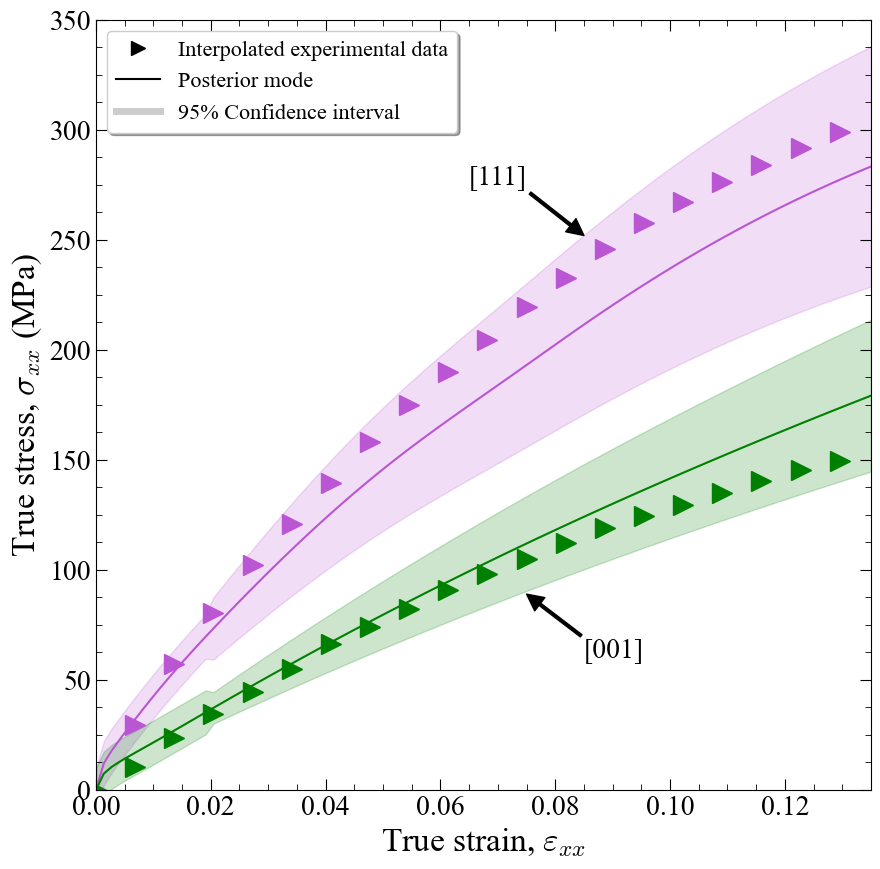

In [250]:
fig_cali_pheno = plt.figure(figsize = (10,10))
ax_cali_pheno = fig_cali_pheno.add_subplot(1,1,1)

#ax_cali_pheno.set_title('Phenopowerlaw calibration', fontsize = 24)

# 1a. From mean values
ax_cali_pheno.plot(strain_incs, y_opt_pheno_111[0], color='mediumorchid',ls='-')
ax_cali_pheno.plot(strain_incs, y_opt_pheno_001[0], color='g',ls='-')

# 1b. From means of Gaussian fit
#ax_cali_pheno.plot(strain_incs, y_opt_pheno_111_gaussian_fit[0], color='mediumorchid',ls='-')
#ax_cali_pheno.plot(strain_incs, y_opt_pheno_001_gaussian_fit[0], color='g',ls='-')

# Experimental curves
ax_cali_pheno.plot(strain_incs[::5], interp_exp_111_stress[::5],color='mediumorchid',ls='None', marker = '>', markersize = 14)#lw=3)
ax_cali_pheno.plot(strain_incs[::5], interp_exp_001_stress[::5],color='g',ls='None', marker = '>', markersize = 14)

# Experimental error
#ax_cali.fill_between(strain_incs,interp_exp_stress[0]+2*errors[0],interp_exp_stress[0]-2*errors[0],color='k',alpha=0.2) #range(len(interp_exp_stress))
#ax_cali.fill_between(strain_incs,interp_exp_stress[1]+2*errors[1],interp_exp_stress[1]-2*errors[1],color='g',alpha=0.2) #range(len(interp_exp_stress))

# Surrogate error
#ax_cali_pheno.fill_between(strain_incs,y_opt_pheno_111[0]+2*y_opt_err_pheno_111[0],y_opt_pheno_111[0]-2*y_opt_err_pheno_111[0],color='mediumorchid', alpha=0.2) #range(len(y_opt[0]))
#ax_cali_pheno.fill_between(strain_incs,y_opt_pheno_001[0]+2*y_opt_err_pheno_001[0],y_opt_pheno_001[0]-2*y_opt_err_pheno_001[0],color='g', alpha=0.2) #range(len(y_opt[0]))

# Total uncertainty is GP uncertainty + experimental uncertainty (S_exp)
#ax_cali_pheno.fill_between(strain_incs,y_opt_pheno_111[0]+ 2*S_mode_pheno[0]*y_opt_pheno_111[0], y_opt_pheno_111[0]- 2*S_mode_pheno[0]*y_opt_pheno_111[0], color='r', alpha=0.2) #range(len(y_opt[0]))
#ax_cali_pheno.fill_between(strain_incs,y_opt_pheno_001[0]+ 2*S_mode_pheno[0]*y_opt_pheno_001[0], y_opt_pheno_001[0]- 2*S_mode_pheno[0]*y_opt_pheno_001[0], color='b', alpha=0.2) #range(len(y_opt[0]))

# Error with calibrated experimental uncertainty value
# 2a. From mean values
#error_opt_pheno_111 = np.maximum(np.ones_like(y_opt_pheno_111[0])*5, S_pheno_mean_and_stdev[0]*y_opt_pheno_111[0])
#error_opt_pheno_001 = np.maximum(np.ones_like(y_opt_pheno_001[0])*5, S_pheno_mean_and_stdev[0]*y_opt_pheno_001[0])

#error_opt_pheno_111 = S_mode_pheno[0]*y_opt_pheno_111[0] + 5
#error_opt_pheno_001 = S_mode_pheno[0]*y_opt_pheno_001[0] + 5

error_opt_pheno_111 = pheno_111_exp_err
error_opt_pheno_001 = pheno_001_exp_err

# 2b. From means of Gaussian fit
#error_opt_pheno_111 = np.maximum(np.ones_like(y_opt_pheno_111_gaussian_fit[0])*5, S_mode_pheno[0]*y_opt_pheno_111_gaussian_fit[0])
#error_opt_pheno_001 = np.maximum(np.ones_like(y_opt_pheno_001_gaussian_fit[0])*5, S_mode_pheno[0]*y_opt_pheno_001_gaussian_fit[0])

# 3a. From mean values
ax_cali_pheno.fill_between(strain_incs,y_opt_pheno_111[0]+ 2*(error_opt_pheno_111), y_opt_pheno_111[0]- 2*(error_opt_pheno_111), color='mediumorchid', alpha=0.2) #range(len(y_opt[0]))
ax_cali_pheno.fill_between(strain_incs,y_opt_pheno_001[0]+ 2*(error_opt_pheno_001), y_opt_pheno_001[0]- 2*(error_opt_pheno_001), color='g', alpha=0.2) #range(len(y_opt[0]))

# 3b. From means of Gaussian fit
#ax_cali_pheno.fill_between(strain_incs,y_opt_pheno_111_gaussian_fit[0]+ 2*(error_opt_pheno_111), y_opt_pheno_111_gaussian_fit[0]- 2*(error_opt_pheno_111), color='mediumorchid', alpha=0.2) #range(len(y_opt[0]))
#ax_cali_pheno.fill_between(strain_incs,y_opt_pheno_001_gaussian_fit[0]+ 2*(error_opt_pheno_001), y_opt_pheno_001_gaussian_fit[0]- 2*(error_opt_pheno_001), color='g', alpha=0.2) #range(len(y_opt[0]))

# Direct simulations from calibrated parameter sets

#ax_unc.plot(direct_dislo_111_strain, direct_dislo_111_stress, color='magenta', ls = '-.')
#ax_unc.plot(direct_dislo_001_strain, direct_dislo_001_stress, color='orange', ls = '-.')

legend_elements_cali_pheno = [Line2D([0],[0], color = 'k', label = 'Interpolated experimental data', marker = '>', markersize = 10, ls = 'None'),
                              Line2D([0],[0], color = 'k', label = 'Posterior mode'),
                              Line2D([0],[0], color = 'k', label = '95% Confidence interval', lw = 5, alpha = 0.2)]

#legend_elements_cali_pheno = [Line2D([0], [0], color='k', label='Observation 111',marker = '>', ls = 'None'),
#                   #Line2D([0], [0], color='k', label='Observation CI 111 ', lw=5,alpha=0.2),
#                   Line2D([0], [0], color='g', label='Observation 001',marker = '>', ls = 'None'),
#                   #Line2D([0], [0], color='g', label='Observation CI 001 ', lw=5,alpha=0.2),
#                   Line2D([0], [0], color='r', label='Posterior mode 111'),
#                   Line2D([0], [0], color='r', label='Posterior CI 111', lw=5,alpha=0.2),
#                   Line2D([0], [0], color='b', label='Posterior mode 001'),
#                   #Line2D([0], [0], color='k', label='Observation CI 111 ', lw=5,alpha=0.2),
#                   Line2D([0], [0], color='b', label='Posterior CI 001', lw=5,alpha=0.2),
                   #Line2D([0], [0], color='g', label='Phenopowerlaw simulation', ls='dashdot'),
                   #Line2D([0], [0], color = 'magenta', ls = '-.', label = 'Direct [111] sim', lw = 5),
                   #Line2D([0], [0], color = 'orange', ls = '-.', label = 'Direct [001] sim', lw = 5)
#                    ]

ax_cali_pheno.set_xlim(0, max(strain_incs))
ax_cali_pheno.set_ylim(0,350)
ax_cali_pheno.set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize = 24, math_fontfamily = 'cm')
ax_cali_pheno.set_ylabel(r'True stress, $\sigma_{xx}$ (MPa)', fontsize = 24, math_fontfamily = 'cm')
ax_cali_pheno.tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 20)
ax_cali_pheno.tick_params(which = 'minor', length = 4)
ax_cali_pheno.tick_params(which = 'major', length = 8)

ax_cali_pheno.xaxis.set_minor_locator(AutoMinorLocator(4))
ax_cali_pheno.yaxis.set_minor_locator(AutoMinorLocator(4))

ax_cali_pheno.annotate('[111]', xy=(0.085, 252), xytext=(0.065,275), color = 'k', fontsize = 20, arrowprops=dict(facecolor = 'k', edgecolor = 'k', width = 2))
ax_cali_pheno.annotate('[001]', xy=(0.075, 89), xytext=(0.085,60), color = 'k', fontsize = 20, arrowprops=dict(facecolor = 'k', edgecolor = 'k', width = 2))

ax_cali_pheno.legend(handles=legend_elements_cali_pheno, ncol=1, fontsize = 16, shadow = True)

#plt.savefig('./phenopowerlaw_calibrated_stress-strain_curves_with_exp_uncertainty.png', dpi=800)

# 7. Sensitivity analysis

In [146]:
# Set parameter ranges according to MCMC posteriors
posterior_param_range = np.array([[0.5,3], [0.4,3.5], [120,420], [270,375]])

pheno_surrogates[0].parameter_range = posterior_param_range
pheno_surrogates[1].parameter_range = posterior_param_range

In [54]:
mean_stdevs = [a_means_and_stdevs[1][0], xi_0_mean_and_stdev[1], xi_inf_means_and_stdevs[1][0], h_0_mean_and_stdev[1]]

In [55]:
pheno_surrogates[0].parameter_mean = mean_params
pheno_surrogates[1].parameter_mean = mean_params
pheno_surrogates[0].parameter_std = mean_stdevs
pheno_surrogates[1].parameter_std = mean_stdevs


In [191]:
local_sobol_pheno_111 = pheno_surrogates[0].generate_sobol(n=2**10, use_fit=False)
local_sobol_pheno_001 = pheno_surrogates[1].generate_sobol(n=2**10, use_fit=False)
boot_pheno_111 = local_sobol_pheno_111.bootstrap()
boot_pheno_001 = local_sobol_pheno_001.bootstrap()

/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/stats/_sensitivity_analysis.py:149: RuntimeWarning: invalid value encountered in divide
  s = np.mean(f_B * (f_AB - f_A), axis=-1) / var  # Table 2 (b)
/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/stats/_sensitivity_analysis.py:150: RuntimeWarning: invalid value encountered in divide
  st = 0.5 * np.mean((f_A - f_AB) ** 2, axis=-1) / var  # Table 2 (f)
/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


In [183]:
pheno_fitting_param_names

['$\\it{a}$',
 '$\\it{\\xi}_{0}[\\text{MPa}]$',
 '$\\it{\\xi}_{\\infty}[\\text{MPa}]$',
 '$\\it{h}_{0}^{\\it{s-s}}[\\text{MPa}]$']

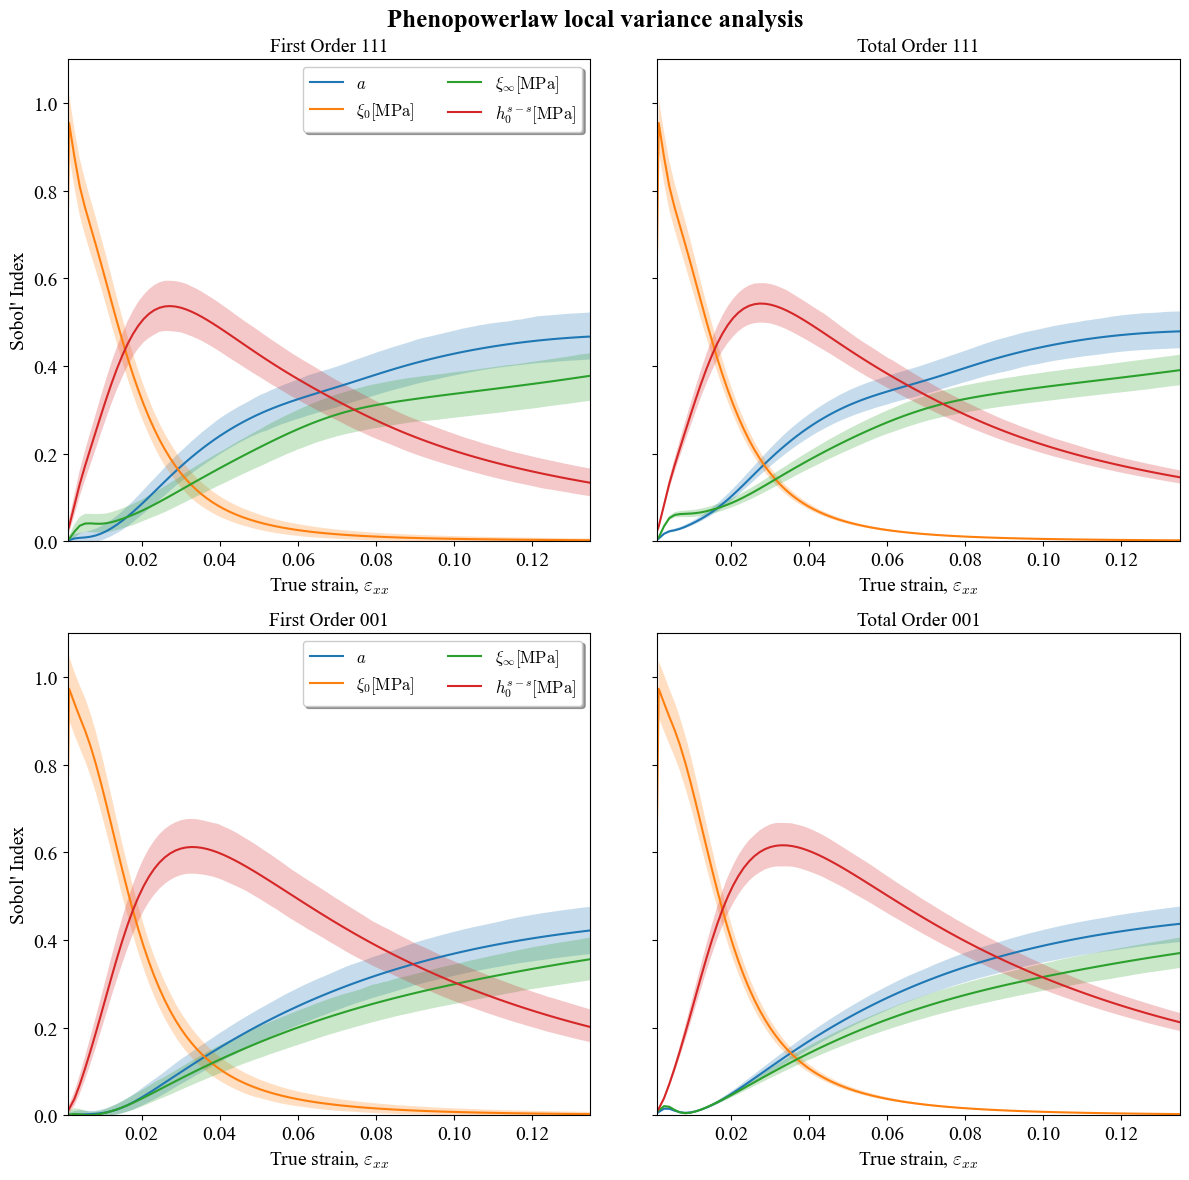

In [189]:
fig_pheno_sobol,axs_pheno_sobol=plt.subplots(2,2,sharey=True,figsize=(12,12))

for i in range(len(pheno_fitting_param_names)):

    axs_pheno_sobol[0][0].fill_between(x=strain_incs,
                    y1=boot_pheno_111.first_order.confidence_interval.low[:,i],
                    y2=boot_pheno_111.first_order.confidence_interval.high[:,i],
                    alpha=0.25)
    axs_pheno_sobol[0][1].fill_between(x=strain_incs,
                    y1=boot_pheno_111.total_order.confidence_interval.low[:,i],
                    y2=boot_pheno_111.total_order.confidence_interval.high[:,i],
                    alpha=0.25)
    axs_pheno_sobol[1][0].fill_between(x=strain_incs,
                    y1=boot_pheno_001.first_order.confidence_interval.low[:,i],
                    y2=boot_pheno_001.first_order.confidence_interval.high[:,i],
                    alpha=0.25)
    axs_pheno_sobol[1][1].fill_between(x=strain_incs,
                    y1=boot_pheno_001.total_order.confidence_interval.low[:,i],
                    y2=boot_pheno_001.total_order.confidence_interval.high[:,i],
                    alpha=0.25)
    
    axs_pheno_sobol[0][0].plot(strain_incs,local_sobol_pheno_111.first_order[:,i],label=fr'{pheno_fitting_param_names[i]}') #label=fitting_param_names[i])
    axs_pheno_sobol[0][1].plot(strain_incs,local_sobol_pheno_111.total_order[:,i],label=fr'{pheno_fitting_param_names[i]}')
    axs_pheno_sobol[1][0].plot(strain_incs,local_sobol_pheno_001.first_order[:,i],label=fr'{pheno_fitting_param_names[i]}') #label=fitting_param_names[i])
    axs_pheno_sobol[1][1].plot(strain_incs,local_sobol_pheno_001.total_order[:,i],label=fr'{pheno_fitting_param_names[i]}')

#Graph stuff
fig_pheno_sobol.suptitle('Phenopowerlaw local variance analysis',weight='bold', fontsize = 18)
#fig.suptitle('Polycrystalline copper variance analysis',weight='bold', fontsize = 18)

L_111 = axs_pheno_sobol[0][0].legend(loc = (0.45, 0.85), ncol = 2, fontsize = 12, shadow = True)
axs_pheno_sobol[0][0].set_ylabel("Sobol' Index", fontsize=14)
axs_pheno_sobol[0][0].set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize=14, math_fontfamily = 'cm')
axs_pheno_sobol[0][1].set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize=14, math_fontfamily = 'cm')

L_001 = axs_pheno_sobol[1][0].legend(loc = (0.45, 0.85), ncol = 2, fontsize = 12, shadow = True)
axs_pheno_sobol[1][0].set_ylabel("Sobol' Index", fontsize=14)
axs_pheno_sobol[1][0].set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize=14, math_fontfamily = 'cm')
axs_pheno_sobol[1][1].set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize=14, math_fontfamily = 'cm')
#axs[0].set_xscale('log')
#axs[1].set_xscale('log')
#axs_pheno_sobol[0][0].set_xlim(min(strain_incs), max(strain_incs))
#axs_pheno_sobol[0][1].set_xlim(min(strain_incs), max(strain_incs))
#axs_pheno_sobol[1][0].set_xlim(min(strain_incs), max(strain_incs))
#axs_pheno_sobol[1][1].set_xlim(min(strain_incs), max(strain_incs))
#axs[0].set_ylim(1e-3)
#axs[1].set_ylim(1e-3)

for text in L_111.get_texts():
    text.set_math_fontfamily('cm')
for text in L_001.get_texts():
    text.set_math_fontfamily('cm')


axs_pheno_sobol[0][0].set_xlim(0.001, max(strain_incs))
axs_pheno_sobol[0][1].set_xlim(0.001, max(strain_incs))
axs_pheno_sobol[1][0].set_xlim(0.001, max(strain_incs))
axs_pheno_sobol[1][1].set_xlim(0.001, max(strain_incs))

axs_pheno_sobol[0][0].set_ylim(0)
axs_pheno_sobol[0][1].set_ylim(0)
axs_pheno_sobol[1][0].set_ylim(0)
axs_pheno_sobol[1][1].set_ylim(0)



axs_pheno_sobol[0][0].set_title('First Order 111', fontsize=14)
axs_pheno_sobol[0][1].set_title('Total Order 111', fontsize=14)
axs_pheno_sobol[1][0].set_title('First Order 001', fontsize=14)
axs_pheno_sobol[1][1].set_title('Total Order 001', fontsize=14)
axs_pheno_sobol[0][0].tick_params(labelsize=14)
axs_pheno_sobol[0][1].tick_params(labelsize=14)
axs_pheno_sobol[1][0].tick_params(labelsize=14)
axs_pheno_sobol[1][1].tick_params(labelsize=14)
#axs[0].set_yscale('log')
#axs[1].set_yscale('log')

fig_pheno_sobol.tight_layout()

In [192]:
local_sobol_pheno_111_final = pheno_surrogates[0].generate_sobol(n=2**12, use_fit=False)
boot_pheno_111_final = local_sobol_pheno_111_final.bootstrap()

/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/stats/_sensitivity_analysis.py:149: RuntimeWarning: invalid value encountered in divide
  s = np.mean(f_B * (f_AB - f_A), axis=-1) / var  # Table 2 (b)
/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/stats/_sensitivity_analysis.py:150: RuntimeWarning: invalid value encountered in divide
  st = 0.5 * np.mean((f_A - f_AB) ** 2, axis=-1) / var  # Table 2 (f)
/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


In [234]:
from itertools import cycle
SA_lines_first = ["-","--","-.",":"]
SA_lines_total = ["-","--","-.",":"]
SA_linecycler_first = cycle(SA_lines_first)
SA_linecycler_total = cycle(SA_lines_total)

colors_first = ["mediumorchid", "green", "c", "red"]
colors_total = ["mediumorchid", "green", "c", "red"]
color_cycler_first = cycle(colors_first)
color_cycler_total = cycle(colors_total)

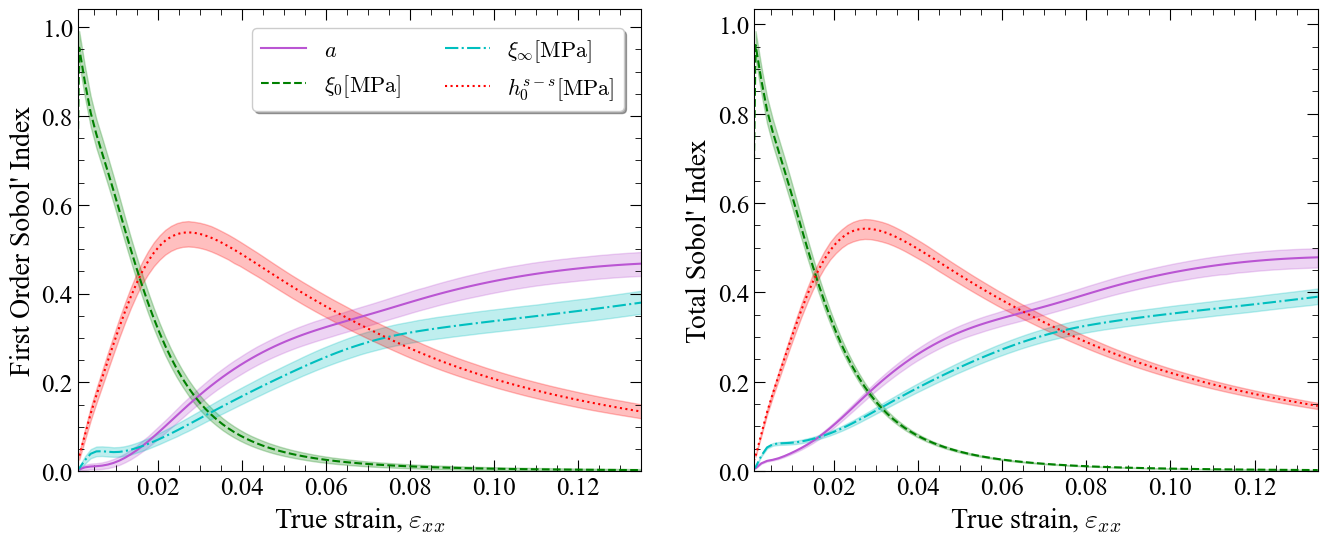

In [245]:
fig_pheno_sobol_111,axs_pheno_sobol_111=plt.subplots(1,2,sharey=False,figsize=(16,6))

for i in range(len(pheno_fitting_param_names)):

    color = next(color_cycler_first)

    axs_pheno_sobol_111[0].fill_between(x=strain_incs,
                    y1=boot_pheno_111_final.first_order.confidence_interval.low[:,i],
                    y2=boot_pheno_111_final.first_order.confidence_interval.high[:,i],
                    alpha=0.25,
                    color = color)
    axs_pheno_sobol_111[1].fill_between(x=strain_incs,
                    y1=boot_pheno_111_final.total_order.confidence_interval.low[:,i],
                    y2=boot_pheno_111_final.total_order.confidence_interval.high[:,i],
                    alpha=0.25,
                    color = color)
    
    axs_pheno_sobol_111[0].plot(strain_incs,local_sobol_pheno_111_final.first_order[:,i], ls = next(SA_linecycler_first), color = color, label=fr'{pheno_fitting_param_names[i]}')
    axs_pheno_sobol_111[1].plot(strain_incs,local_sobol_pheno_111_final.total_order[:,i], ls = next(SA_linecycler_total), color = color, label=fr'{pheno_fitting_param_names[i]}')

L_111_final = axs_pheno_sobol_111[0].legend(loc = (0.31, 0.78), ncol = 2, fontsize = 16, shadow = True)
axs_pheno_sobol_111[0].set_ylabel("First Order Sobol' Index", fontsize=20)
axs_pheno_sobol_111[1].set_ylabel("Total Sobol' Index", fontsize=20)
axs_pheno_sobol_111[0].set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize=20, math_fontfamily = 'cm')
axs_pheno_sobol_111[1].set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize=20, math_fontfamily = 'cm')

for text in L_111_final.get_texts():
    text.set_math_fontfamily('cm')


axs_pheno_sobol_111[0].set_xlim(0.001, max(strain_incs))
axs_pheno_sobol_111[1].set_xlim(0.001, max(strain_incs))

axs_pheno_sobol_111[0].set_ylim(0)
axs_pheno_sobol_111[1].set_ylim(0)

axs_pheno_sobol_111[0].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 18)
axs_pheno_sobol_111[0].tick_params(which = 'minor', length = 4)
axs_pheno_sobol_111[0].tick_params(which = 'major', length = 8)

axs_pheno_sobol_111[1].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 18)
axs_pheno_sobol_111[1].tick_params(which = 'minor', length = 4)
axs_pheno_sobol_111[1].tick_params(which = 'major', length = 8)

axs_pheno_sobol_111[0].xaxis.set_minor_locator(AutoMinorLocator(4))
axs_pheno_sobol_111[0].yaxis.set_minor_locator(AutoMinorLocator(4))
axs_pheno_sobol_111[1].xaxis.set_minor_locator(AutoMinorLocator(4))
axs_pheno_sobol_111[1].yaxis.set_minor_locator(AutoMinorLocator(4))

plt.savefig('./plots/sobol_SA/phenopowerlaw_sobol_sensitivity_analysis.png', dpi = 800)


For polycrystal simulation

In [58]:
for i in range(len(mean_params)):
    print(mean_params[i])

1.057229611938016
2.1157748057658714
142.5790011963368
315.9437554128178
